In [ ]:
from sklearn.preprocessing import StandardScaler
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.layers import SimpleRNN, Dense, Dropout, LSTM, GRU
from tensorflow import keras
from sklearn.metrics import accuracy_score, matthews_corrcoef, precision_score, recall_score
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
pos=pd.read_csv('/content/drive/MyDrive/Thesis/Pos Dataset.csv')
neg=pd.read_csv('/content/drive/MyDrive/Thesis/Neg Dataset.csv')
#random_records = df_neg.sample(n=6000, random_state=42)
#df = pd.concat([random_records, df_pos], ignore_index=True)
df = pd.concat([neg, pos], ignore_index=True)


In [ ]:
df

,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,...,C145,C146,C147,C148,C149,C150,C151,C152,C153,class
0,531,2467,14033,88213,2045,9452,53370,9905,44820,54095,...,28,137,103,7,90,109,0,55,0,0
1,195,531,1685,5811,475,1284,4082,1421,3788,4765,...,5,13,20,0,0,0,14,15,0,0
2,693,3402,21462,152736,3026,14658,91996,16356,77072,98978,...,447,65,187,183,131,0,35,33,0,0
3,1186,7076,53318,450110,6450,37749,281991,43748,251579,329814,...,607,267,43,704,419,595,93,99,0,0
4,1892,13982,134666,1468904,13294,98340,948360,118710,875948,1192252,...,664,289,478,1652,1388,1140,130,292,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11345,6492,87389,1536921,30454451,83938,1116033,19400871,1417372,18625591,26867074,...,5113,11797,10595,18379,12169,6839,1091,4748,0,1
11346,4722,53411,795737,13359665,48955,548913,8195235,662033,7343421,10108807,...,4655,5791,1733,8018,6517,5932,1067,5026,0,1
11347,2238,19136,212112,2638694,17070,143295,1571849,169830,1404347,1907250,...,824,1237,576,1360,1377,1795,507,1172,0,1
11348,2717,23785,273447,3551767,21986,188048,2130904,230326,1926166,2728436,...,594,1264,1061,3666,2102,3766,434,1461,0,1


In [ ]:
X=df.drop(['class'],axis=1)
y=df['class']

In [ ]:
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True)

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
std_scale = MinMaxScaler().fit(X)
X = std_scale.fit_transform(X)

In [ ]:
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True)

input_dim=153
num_classes=2
# Reshape input dataone hot enciding to pandas series
X = X.reshape(-1, input_dim)
#X_test = X_test.reshape(-1, input_dim)

# # Convert output data to one-hot encoding
y = tf.keras.utils.to_categorical(y, num_classes)
#y_test = tf.keras.utils.to_categorical(y_test, num_classes)

In [ ]:
X.shape


(11350, 153)

#FCN **Model**

In [ ]:
# Define the ANN model architecture with multiple hidden layers
ann_model = Sequential()
ann_model.add(Dense(128, input_dim=X.shape[1], activation='relu'))
ann_model.add(Dense(64, activation='relu'))
ann_model.add(Dense(32, activation='relu'))
ann_model.add(Dense(16, activation='relu'))
ann_model.add(Dense(8, activation='relu'))
ann_model.add(Dense(2, activation='softmax'))  # Output layer changed for 2 classes

# Compile the model using categorical_crossentropy for multi-class
ann_model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train the model on the entire dataset
ann_model.fit(X, y, epochs=10, batch_size=32, validation_data=(X, y))

Epoch 1/100
355/355 ━━━━━━━━━━━━━━━━━━━━ 18s 42ms/step - accuracy: 0.7735 - loss: 0.5082 - val_accuracy: 0.9354 - val_loss: 0.3116
Epoch 2/100
355/355 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9345 - loss: 0.3065 - val_accuracy: 0.9382 - val_loss: 0.2572
Epoch 3/100
355/355 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9341 - loss: 0.2666 - val_accuracy: 0.9414 - val_loss: 0.2402
Epoch 4/100
355/355 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9394 - loss: 0.2371 - val_accuracy: 0.9230 - val_loss: 0.2576
Epoch 5/100
355/355 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9453 - loss: 0.2089 - val_accuracy: 0.9253 - val_loss: 0.2353
Epoch 6/100
355/355 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9402 - loss: 0.2053 - val_accuracy: 0.9469 - val_loss: 0.1883
Epoch 7/100
355/355 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9436 - loss: 0.1947 - val_accuracy: 0.9514 - val_loss: 0.1816
Epoch 8/100
355/355 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9463 - loss: 0.1842 - val_ac

In [ ]:
ann_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                     │ (None, 128)                 │          19,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_14 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_15 (Dense)                     │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_16 (Dense)                     │ (None, 8)                   │             136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_17 (Dense)                     │ (None, 2)                   │              18 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 92,192 (360.13 KB)

 Trainable params: 30,730 (120.04 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 61,462 (240.09 KB)

Dense Layer 1 = (153 + 1) * 264 = 154 * 264 = 40656 <br>
Dense Layer 2 = (264 + 1) * 128 = 265 * 128 = 33920 <br>
Dense Layer 3 = (128 + 1) * 64 = 129 * 64 = 8256 <br>
Dense Layer 3 = (64 + 1) * 2 = 65 * 2 = 130


In [ ]:
# Get the predictions from the best model
y_pred = ann_model.predict(X)

# Convert the predictions to binary labels
y_pred_labels = np.argmax(y_pred, axis=1)

# Convert the true labels to binary labels
y_labels = np.argmax(y, axis=1)

# Calculate accuracy
accuracy = accuracy_score(y_labels, y_pred_labels)

# Calculate MCC
mcc = matthews_corrcoef(y_labels, y_pred_labels)

# Calculate specificity
specificity = recall_score(y_labels, y_pred_labels, pos_label=0)

# Calculate sensitivity
sensitivity = recall_score(y_labels, y_pred_labels, pos_label=1)
print("ANN")
print("Accuracy:", accuracy)
print("MCC:", mcc)
print("Specificity:", specificity)
print("Sensitivity:", sensitivity)

355/355 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
ANN
Accuracy: 0.9345374449339207
MCC: 0.8598817534884481
Specificity: 1.0
Sensitivity: 0.814110582937203


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# Use predict to get probabilities for Keras models
y_pred_proba = ann_model.predict(X)

# For binary classification, select the probability of the positive class
y_pred_proba = y_pred_proba[:, 1]

ann_fpr, ann_tpr, thresholds = roc_curve(y_labels, y_pred_proba)
ann_roc_auc = roc_auc_score(y_labels, y_pred_proba)

355/355 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


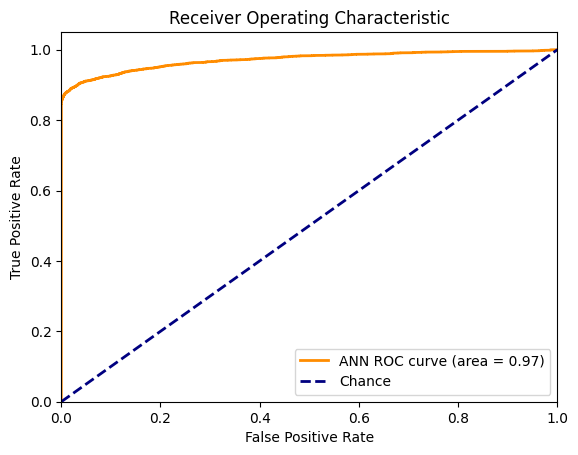

In [ ]:
plt.figure()

plt.plot(ann_fpr, ann_tpr, color='darkorange', lw=2, label='ANN ROC curve (area = %0.2f)' % ann_roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2,label="Chance" ,linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

355/355 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


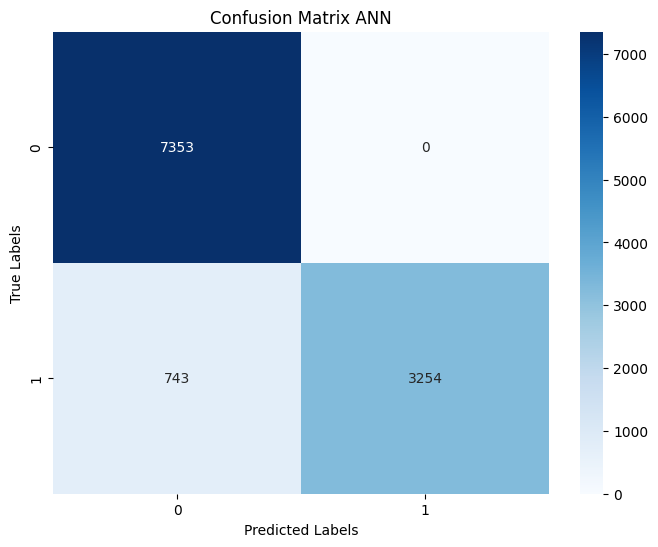

In [ ]:

# Assuming your model is already trained and you have test data X_test, y_test

# Predict classes using the trained model
y_pred = np.argmax(ann_model.predict(X), axis=1)

# Calculate confusion matrix
cm = confusion_matrix(np.argmax(y, axis=1), y_pred)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix ANN')
plt.show()


In [ ]:
cnn_model = Sequential()

# Adding the first convolutional layer with 64 filters, kernel size 3, and ReLU activation function
cnn_model.add(Conv1D(64, kernel_size=3, activation='relu', input_shape=(input_dim,1)))

# Adding a max pooling layer
cnn_model.add(MaxPooling1D(pool_size=2))

# Adding the second convolutional layer with 32 filters, kernel size 3, and ReLU activation function
cnn_model.add(Conv1D(32, kernel_size=3, activation='relu'))

# Adding a max pooling layer
cnn_model.add(MaxPooling1D(pool_size=2))

# Adding the third convolutional layer with 16 filters, kernel size 3, and ReLU activation function
cnn_model.add(Conv1D(16, kernel_size=3, activation='relu'))

# Adding a max pooling layer
cnn_model.add(MaxPooling1D(pool_size=2))

# Flattening the output of the convolutional layers
cnn_model.add(Flatten())

# Adding a fully connected layer with 128 neurons and ReLU activation function
cnn_model.add(Dense(128, activation='relu'))

# Adding a dropout layer to handle overfitting
cnn_model.add(Dropout(0.5))  # Adjust dropout rate as needed

# Adding a fully connected layer with 64 neurons and ReLU activation function
cnn_model.add(Dense(64, activation='relu'))

# Adding a dropout layer to handle overfitting
cnn_model.add(Dropout(0.5))  # Adjust dropout rate as needed

# Adding the output layer with appropriate activation function (e.g., softmax for classification)
cnn_model.add(Dense(num_classes, activation='softmax'))

# Compile the model
cnn_model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train the model
cnn_model.fit(X, y, epochs=100, batch_size=32, validation_data=(X, y))

Epoch 1/100


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


355/355 ━━━━━━━━━━━━━━━━━━━━ 14s 26ms/step - accuracy: 0.7412 - loss: 0.5195 - val_accuracy: 0.9426 - val_loss: 0.1782
Epoch 2/100
355/355 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9311 - loss: 0.2078 - val_accuracy: 0.9091 - val_loss: 0.2505
Epoch 3/100
355/355 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9336 - loss: 0.2020 - val_accuracy: 0.9326 - val_loss: 0.1927
Epoch 4/100
355/355 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9325 - loss: 0.2025 - val_accuracy: 0.9468 - val_loss: 0.1883
Epoch 5/100
355/355 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9397 - loss: 0.1909 - val_accuracy: 0.9449 - val_loss: 0.1713
Epoch 6/100
355/355 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9393 - loss: 0.1870 - val_accuracy: 0.9490 - val_loss: 0.1627
Epoch 7/100
355/355 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9363 - loss: 0.1965 - val_accuracy: 0.9493 - val_loss: 0.1649
Epoch 8/100
355/355 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9435 - loss: 0.1745 - val_accuracy: 0.95

In [ ]:
# Get the predictions from the best model
y_pred = cnn_model.predict(X)

# Convert the predictions to binary labels
y_pred_labels = np.argmax(y_pred, axis=1)

# Convert the true labels to binary labels
y_true_labels = np.argmax(y, axis=1)

# Calculate accuracy
accuracy = accuracy_score(y_true_labels, y_pred_labels)

# Calculate MCC
mcc = matthews_corrcoef(y_true_labels, y_pred_labels)

# Calculate specificity
specificity = recall_score(y_true_labels, y_pred_labels, pos_label=0)

# Calculate sensitivity
sensitivity = recall_score(y_true_labels, y_pred_labels, pos_label=1)
print("CNN")
print("Test Accuracy:", accuracy)
print("Test MCC:", mcc)
print("Test Specificity:", specificity)
print("Test Sensitivity:", sensitivity)

355/355 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
CNN
Test Accuracy: 0.9604405286343612
Test MCC: 0.9135446633782842
Test Specificity: 0.9917040663674691
Test Sensitivity: 0.9029271953965474


355/355 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


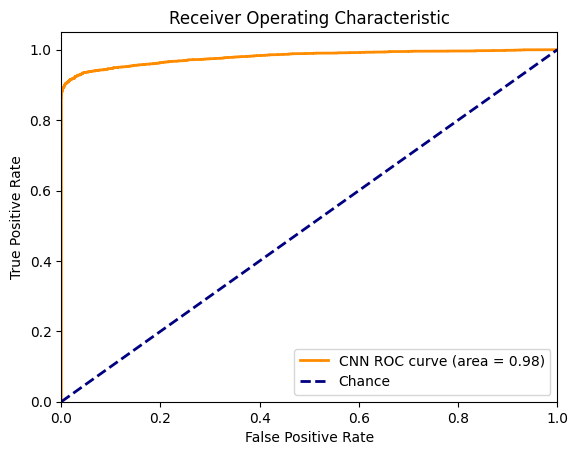

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# Use predict to get probabilities for Keras models
y_pred_proba = cnn_model.predict(X)

# For binary classification, select the probability of the positive class
y_pred_proba = y_pred_proba[:, 1]

cnn_fpr, cnn_tpr, thresholds = roc_curve(y_labels, y_pred_proba)
cnn_roc_auc = roc_auc_score(y_labels, y_pred_proba)
plt.figure()

plt.plot(cnn_fpr, cnn_tpr, color='darkorange', lw=2, label='CNN ROC curve (area = %0.2f)' % cnn_roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2,label="Chance" ,linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

355/355 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


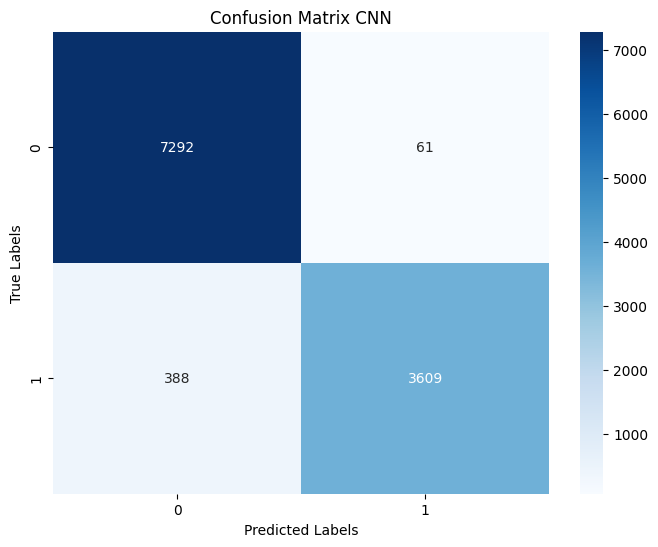

In [ ]:
y_pred = np.argmax(cnn_model.predict(X), axis=1)
cm = confusion_matrix(np.argmax(y, axis=1), y_pred)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix CNN')
plt.show()


In [ ]:
X.shape

(11350, 153)

In [ ]:
# Reshape input data
timestamp=1
X = X.reshape(X.shape[0], timestamp, X.shape[1])
#X_test = X_test.reshape(X.shape[0], timestamp, X_test.shape[1])

In [ ]:
timestamp=1
# Define the SimpleRNN model architecture with multiple hidden layers
rnn_model = Sequential()
rnn_model.add(SimpleRNN(128, input_shape=(timestamp,input_dim), return_sequences=True)) # First SimpleRNN layer with return_sequences=True
rnn_model.add(SimpleRNN(64, return_sequences=True))  # Second SimpleRNN layer with return_sequences=True
rnn_model.add(SimpleRNN(32, return_sequences=True))  # Third SimpleRNN layer with return_sequences=True
rnn_model.add(SimpleRNN(16, return_sequences=True))  # Fourth SimpleRNN layer with return_sequences=True
rnn_model.add(SimpleRNN(8))  # Fifth SimpleRNN layer without return_sequences=True
rnn_model.add(Dense(num_classes, activation='sigmoid'))
# Compile the model
rnn_model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train the model
rnn_model.fit(X, y, epochs=100, batch_size=32, validation_data=(X, y))

/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
355/355 ━━━━━━━━━━━━━━━━━━━━ 59s 99ms/step - accuracy: 0.8280 - loss: 0.4056 - val_accuracy: 0.9184 - val_loss: 0.2347
Epoch 2/100
355/355 ━━━━━━━━━━━━━━━━━━━━ 29s 3ms/step - accuracy: 0.9377 - loss: 0.1930 - val_accuracy: 0.9155 - val_loss: 0.2714
Epoch 3/100
355/355 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9418 - loss: 0.1802 - val_accuracy: 0.9542 - val_loss: 0.1583
Epoch 4/100
355/355 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9357 - loss: 0.1878 - val_accuracy: 0.9401 - val_loss: 0.1733
Epoch 5/100
355/355 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9419 - loss: 0.1793 - val_accuracy: 0.9254 - val_loss: 0.2118
Epoch 6/100
355/355 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9407 - loss: 0.1841 - val_accuracy: 0.9488 - val_loss: 0.1636
Epoch 7/100
355/355 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9449 - loss: 0.1750 - val_accuracy: 0.9447 - val_loss: 0.1685
Epoch 8/100
355/355 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9473 - loss: 0.1677 - val_a

In [ ]:

# Get the predictions from the best model
y_pred = rnn_model.predict(X)

# Convert the predictions to binary labels
y_pred_labels = np.argmax(y_pred, axis=1)

# Convert the true labels to binary labels
y_true_labels = np.argmax(y, axis=1)

# Calculate accuracy
accuracy = accuracy_score(y_true_labels, y_pred_labels)

# Calculate MCC
mcc = matthews_corrcoef(y_true_labels, y_pred_labels)

# Calculate specificity
specificity = recall_score(y_labels, y_pred_labels, pos_label=0)

# Calculate sensitivity
sensitivity = recall_score(y_labels, y_pred_labels, pos_label=1)
print("RNN")
print("Accuracy:", accuracy)
print("MCC:", mcc)
print("Specificity:", specificity)
print("Sensitivity:", sensitivity)

355/355 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
RNN
Accuracy: 0.9557709251101322
MCC: 0.9033253523669593
Specificity: 0.9904800761593907
Sensitivity: 0.8919189392044033


355/355 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


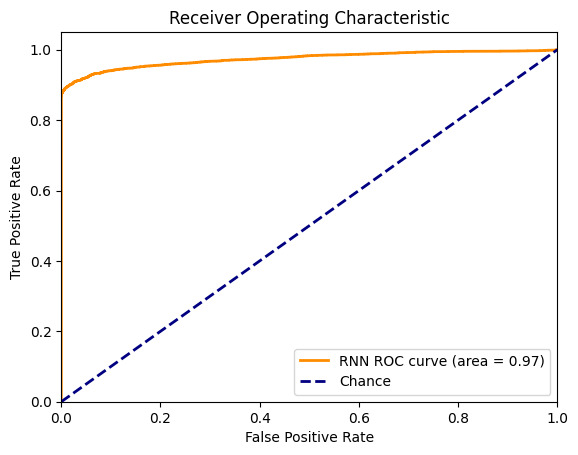

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# Use predict to get probabilities for Keras models
y_pred_proba = rnn_model.predict(X)

# For binary classification, select the probability of the positive class
y_pred_proba = y_pred_proba[:, 1]

rnn_fpr, rnn_tpr, thresholds = roc_curve(y_labels, y_pred_proba)
rnn_roc_auc = roc_auc_score(y_labels, y_pred_proba)
plt.figure()

plt.plot(rnn_fpr,rnn_tpr, color='darkorange', lw=2, label='RNN ROC curve (area = %0.2f)' % rnn_roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2,label="Chance" ,linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

355/355 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


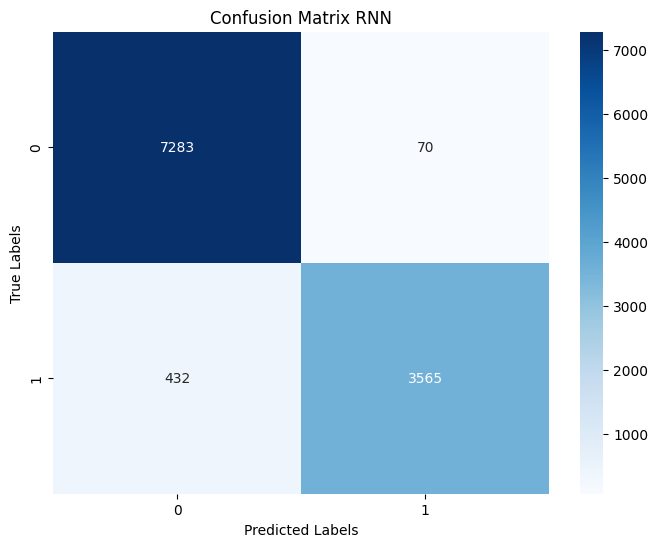

In [ ]:
y_pred = np.argmax(rnn_model.predict(X), axis=1)

# Calculate confusion matrix
cm = confusion_matrix(np.argmax(y, axis=1), y_pred)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix RNN')
plt.show()


In [ ]:
    # Define the LSTM model architecture with multiple hidden layers
    lstm_model = Sequential()
    lstm_model.add(LSTM(128, input_shape=(timestamp,input_dim), return_sequences=True))  # First LSTM layer with return_sequences=True
    lstm_model.add(LSTM(64, return_sequences=True))  # Second LSTM layer with return_sequences=True
    lstm_model.add(LSTM(32, return_sequences=True))  # Third LSTM layer with return_sequences=True
    lstm_model.add(LSTM(16, return_sequences=True))  # Fourth LSTM layer with return_sequences=True
    lstm_model.add(LSTM(8))  # Fifth LSTM layer without return_sequences=True
    lstm_model.add(Dense(num_classes, activation='sigmoid'))

/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
lstm_model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 1, 128)              │         144,384 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 1, 64)               │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_2 (LSTM)                        │ (None, 1, 32)               │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_3 (LSTM)                        │ (None, 1, 16)               │           3,136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_4 (LSTM)                        │ (None, 8)                   │             800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_22 (Dense)                     │ (None, 2)                   │              18 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 210,162 (820.95 KB)

 Trainable params: 210,162 (820.95 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile the model
lstm_model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train the model
lstm_model.fit(X, y, epochs=100, batch_size=32, validation_data=(X, y))

Epoch 1/100
355/355 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.6957 - loss: 0.5981 - val_accuracy: 0.8966 - val_loss: 0.3657
Epoch 2/100
355/355 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.9218 - loss: 0.2633 - val_accuracy: 0.8891 - val_loss: 0.2610
Epoch 3/100
355/355 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9399 - loss: 0.1916 - val_accuracy: 0.9501 - val_loss: 0.1676
Epoch 4/100
355/355 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.9389 - loss: 0.1906 - val_accuracy: 0.9539 - val_loss: 0.1584
Epoch 5/100
355/355 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9447 - loss: 0.1765 - val_accuracy: 0.9506 - val_loss: 0.1599
Epoch 6/100
355/355 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9380 - loss: 0.1939 - val_accuracy: 0.9502 - val_loss: 0.1614
Epoch 7/100
355/355 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9424 - loss: 0.1769 - val_accuracy: 0.9375 - val_loss: 0.1786
Epoch 8/100
355/355 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9459 - loss: 0.1668 -

In [ ]:

y_pred = lstm_model.predict(X)

# Convert the predictions to binary labels
y_pred_labels = np.argmax(y_pred, axis=1)

# Convert the true labels to binary labels
y_true_labels = np.argmax(y, axis=1)

# Calculate accuracy
accuracy = accuracy_score(y_true_labels, y_pred_labels)

# Calculate MCC
mcc = matthews_corrcoef(y_true_labels, y_pred_labels)

# Calculate specificity
specificity = recall_score(y_true_labels, y_pred_labels, pos_label=0)

# Calculate sensitivity
sensitivity = recall_score(y_true_labels, y_pred_labels, pos_label=1)
print("LSTM")
print("Accuracy:", accuracy)
print("MCC:", mcc)
print("Specificity:", specificity)
print("Sensitivity:", sensitivity)

355/355 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
LSTM
Accuracy: 0.9555947136563877
MCC: 0.9032324862240914
Specificity: 0.9929280565755474
Sensitivity: 0.8869151863897924


355/355 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


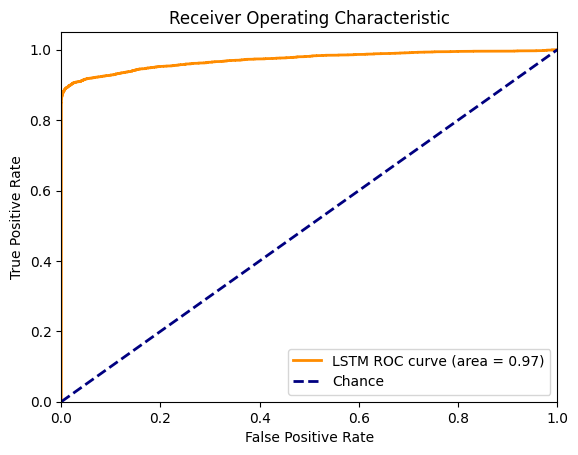

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# Use predict to get probabilities for Keras models
y_pred_proba = lstm_model.predict(X)

# For binary classification, select the probability of the positive class
y_pred_proba = y_pred_proba[:, 1]

lstm_model_fpr, lstm_model_tpr, thresholds = roc_curve(y_labels, y_pred_proba)
lstm_model_roc_auc = roc_auc_score(y_labels, y_pred_proba)
plt.figure()

plt.plot(lstm_model_fpr, lstm_model_tpr, color='darkorange', lw=2, label='LSTM ROC curve (area = %0.2f)' % lstm_model_roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2,label="Chance" ,linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

355/355 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


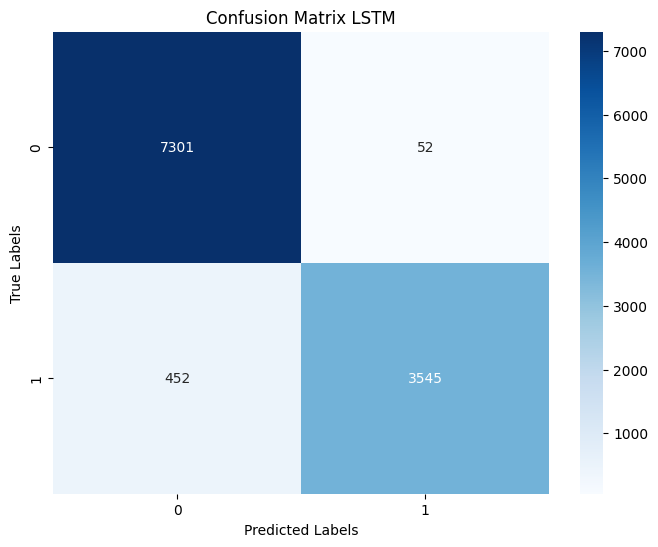

In [ ]:

y_pred = np.argmax(lstm_model.predict(X), axis=1)

# Calculate confusion matrix
cm = confusion_matrix(np.argmax(y, axis=1), y_pred)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix LSTM')
plt.show()


In [ ]:

gru = Sequential()

# Adding the first GRU layer with 64 units and return sequences
gru.add(GRU(64, return_sequences=True, input_shape=(timestamp,input_dim)))

# Adding a dropout layer to handle overfitting
gru.add(Dropout(0.5))  # Adjust dropout rate as needed

# Adding the second GRU layer with 32 units and return sequences
gru.add(GRU(32, return_sequences=True))

# Adding a dropout layer to handle overfitting
gru.add(Dropout(0.5))  # Adjust dropout rate as needed

# Adding the third GRU layer with 16 units and no return sequences
gru.add(GRU(16))

# Adding a dropout layer to handle overfitting
gru.add(Dropout(0.5))  # Adjust dropout rate as needed

# Adding a fully connected layer with 128 neurons and ReLU activation function
gru.add(Dense(128, activation='relu'))

# Adding a dropout layer to handle overfitting
gru.add(Dropout(0.5))  # Adjust dropout rate as needed

# Adding a fully connected layer with 64 neurons and ReLU activation function
gru.add(Dense(64, activation='relu'))

# Adding a dropout layer to handle overfitting
gru.add(Dropout(0.5))  # Adjust dropout rate as needed

# Adding the output layer with appropriate activation function (e.g., softmax for classification)
gru.add(Dense(num_classes, activation='softmax'))
gru.summary()


/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ gru (GRU)                            │ (None, 1, 64)               │          42,048 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 1, 64)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru_1 (GRU)                          │ (None, 1, 32)               │           9,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 1, 32)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru_2 (GRU)                          │ (None, 16)                  │           2,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_23 (Dense)                     │ (None, 128)                 │           2,176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_24 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_25 (Dense)                     │ (None, 2)                   │             130 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 64,418 (251.63 KB)

 Trainable params: 64,418 (251.63 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile the model
gru.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train the model
gru.fit(X, y, epochs=100, batch_size=32, validation_data=(X, y))

Epoch 1/100
355/355 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.6847 - loss: 0.5994 - val_accuracy: 0.9199 - val_loss: 0.2184
Epoch 2/100
355/355 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9075 - loss: 0.2655 - val_accuracy: 0.9196 - val_loss: 0.2155
Epoch 3/100
355/355 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9245 - loss: 0.2315 - val_accuracy: 0.9441 - val_loss: 0.1713
Epoch 4/100
355/355 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9284 - loss: 0.2166 - val_accuracy: 0.9342 - val_loss: 0.1888
Epoch 5/100
355/355 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9326 - loss: 0.2042 - val_accuracy: 0.9404 - val_loss: 0.1750
Epoch 6/100
355/355 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9384 - loss: 0.1910 - val_accuracy: 0.9272 - val_loss: 0.2026
Epoch 7/100
355/355 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9362 - loss: 0.1949 - val_accuracy: 0.9515 - val_loss: 0.1606
Epoch 8/100
355/355 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9404 - loss: 0.1854 - 

In [ ]:

y_pred = gru.predict(X)

# Convert the predictions to binary labels
y_pred_labels = np.argmax(y_pred, axis=1)

# Convert the true labels to binary labels
y_true_labels = np.argmax(y, axis=1)

# Calculate accuracy
accuracy = accuracy_score(y_true_labels, y_pred_labels)

# Calculate MCC
mcc = matthews_corrcoef(y_true_labels, y_pred_labels)

# Calculate specificity
specificity = recall_score(y_true_labels, y_pred_labels, pos_label=0)

# Calculate sensitivity
sensitivity = recall_score(y_true_labels, y_pred_labels, pos_label=1)
print("GRU")
print("Accuracy:", accuracy)
print("MCC:", mcc)
print("Specificity:", specificity)
print("Sensitivity:", sensitivity)

355/355 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
GRU
Accuracy: 0.9570925110132159
MCC: 0.9070658676851664
Specificity: 0.9972800217598259
Sensitivity: 0.8831623717788342


355/355 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


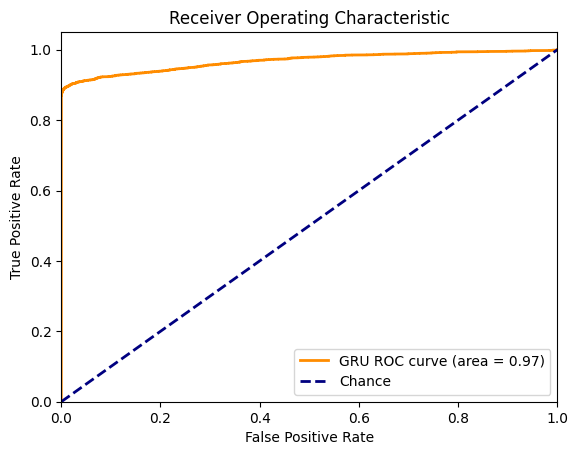

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# Use predict to get probabilities for Keras models
y_pred_proba = gru.predict(X)

# For binary classification, select the probability of the positive class
y_pred_proba = y_pred_proba[:, 1]

gru_fpr, gru_tpr, thresholds = roc_curve(y_labels, y_pred_proba)
gru_roc_auc = roc_auc_score(y_labels, y_pred_proba)
plt.figure()

plt.plot(gru_fpr, gru_tpr, color='darkorange', lw=2, label='GRU ROC curve (area = %0.2f)' % gru_roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2,label="Chance" ,linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

355/355 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


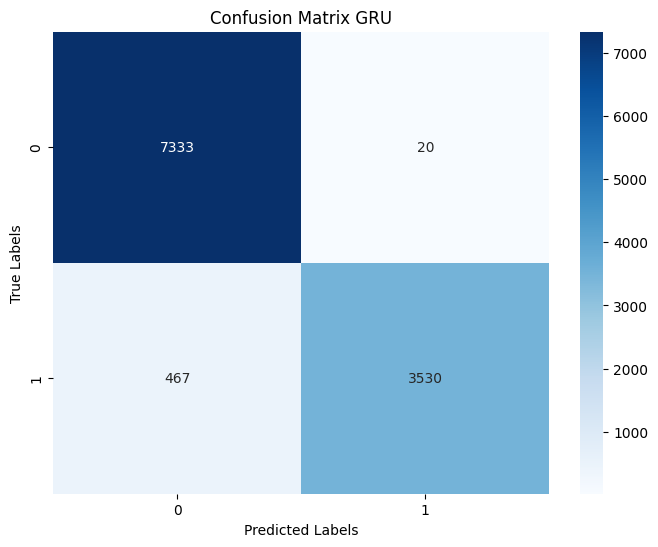

In [ ]:

y_pred = np.argmax(gru.predict(X), axis=1)

# Calculate confusion matrix
cm = confusion_matrix(np.argmax(y, axis=1), y_pred)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix GRU')
plt.show()


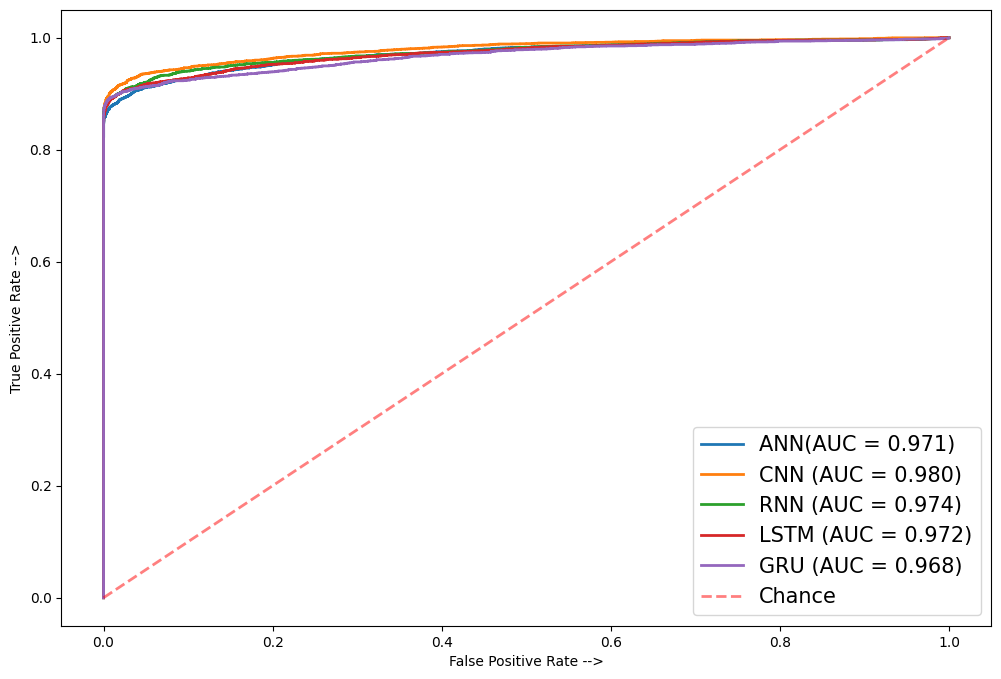

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score


plt.figure(figsize=(12,8))

#plt.plot(lstm_fpr, lstm_tpr, lw=2, label='FCN (auc = %0.4f)' % lstm_auc)
#plt.plot(rnn_fpr, rnn_tpr, lw=2, label='RNN (auc = %0.4f)' % rnn_auc)
plt.plot(ann_fpr, ann_tpr, lw=2, label='ANN(AUC = %0.3f)' % ann_roc_auc)
plt.plot(cnn_fpr, cnn_tpr,  lw=2, label='CNN (AUC = %0.3f)' % cnn_roc_auc)
plt.plot(rnn_fpr, rnn_tpr,  lw=2, label='RNN (AUC = %0.3f)' % rnn_roc_auc)
plt.plot(lstm_model_fpr, lstm_model_tpr,  lw=2, label='LSTM (AUC = %0.3f)' % lstm_model_roc_auc)
plt.plot(gru_fpr, gru_tpr,  lw=2, label='GRU (AUC = %0.3f)' % gru_roc_auc)
plt.plot([0, 1], [0, 1], linestyle="--", lw=2, color="r", label="Chance", alpha=0.5)
#plt.plot([0, 1], [0, 1],  lw=2, color="r", label="Amino Acid Composition ROC Curve", alpha=0.8)

plt.xlabel('False Positive Rate -->')
plt.ylabel('True Positive Rate -->')

plt.legend(loc="lower right", fontsize=15, ncol=1)

plt.show()

In [ ]:
# from keras.callbacks import ModelCheckpoint

# fcncheckpoint = ModelCheckpoint('best_modelfcn.h5', monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)

# best_modeldcn.fit(X_train, y_train, epochs=100, validation_data=(X_test, y_test),callbacks=[fcncheckpoint])

In [ ]:
# from tensorflow import keras
# from sklearn.metrics import accuracy_score, matthews_corrcoef, precision_score, recall_score


# best_modelfcn = keras.models.load_model('/content/best_modelfcn.h5')
# predictions = best_modelfcn.predict(X_test)


# # Get the predictions from the best model
# y_test_pred = best_modeldcn.predict(X_test)

# # Convert the predictions to binary labels
# y_test_pred_labels = np.argmax(y_test_pred, axis=1)

# # Convert the true labels to binary labels
# y_test_true_labels = np.argmax(y_test, axis=1)

# # Calculate accuracy
# test_accuracy = accuracy_score(y_test_true_labels, y_test_pred_labels)

# # Calculate MCC
# test_mcc = matthews_corrcoef(y_test_true_labels, y_test_pred_labels)

# # Calculate specificity
# test_specificity = recall_score(y_test_true_labels, y_test_pred_labels, pos_label=0)

# # Calculate sensitivity
# test_sensitivity = recall_score(y_test_true_labels, y_test_pred_labels, pos_label=1)
# print("FCN")
# print("Test Accuracy:", test_accuracy)
# print("Test MCC:", test_mcc)
# print("Test Specificity:", test_specificity)
# print("Test Sensitivity:", test_sensitivity)

7/7 [==============================] - 0s 2ms/step
FCN
Test Accuracy: 0.7704081632653061
Test MCC: 0.5410699068377959
Test Specificity: 0.7789473684210526
Test Sensitivity: 0.7623762376237624


In [ ]:
# import numpy as np
# from sklearn.metrics import roc_curve, roc_auc_score
# import pandas as pd

# # Get the predicted probabilities from the best model
# y_test_probs = best_modelfcn.predict(X_test)[:, 1]

# # Compute the FPR and TPR for training and testing data
# test_fpr, test_tpr, _ = roc_curve(y_test_true_labels, y_test_probs)

# # Compute the AUC score for training and testing data
# test_auc = roc_auc_score(y_test_true_labels, y_test_probs)

# # Create a DataFrame with FPR and TPR values
# df_fpr_tpr = pd.DataFrame({ "Test FPR": test_fpr, "Test TPR": test_tpr})

# # Save the DataFrame to a CSV file
# df_fpr_tpr.to_csv("FCNfpr_tpr.csv", index=False)

# print("Test AUC:", test_auc)


7/7 [==============================] - 0s 3ms/step
Test AUC: 0.8071912454403335


In [ ]:
# # Reshape input data
# from sklearn.metrics import confusion_matrix
# import tensorflow as tf
# X_train = X_train.reshape(-1, input_dim)
# X_test = X_test.reshape(-1, input_dim)

# # # Convert output data to one-hot encoding
# y_train = tf.keras.utils.to_categorical(y_train, num_classes)
# y_test = tf.keras.utils.to_categorical(y_test, num_classes)
